In [4]:
import pandas as pd
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random 
from latent_regularizer import*

In [485]:
def draw_gmm_samples(num_samples, gmm_centers, gmm_std):
    num_gmm_centers, dimension = gmm_centers.shape
    print(num_gmm_centers, dimension)
    samples = []
    components = []
    for _ in range(num_samples):
        component = np.random.choice(range(num_gmm_centers))

        component_mean = gmm_centers[component, :]
        component_cov = torch.eye(dimension) * gmm_std

        distribution = torch.distributions.multivariate_normal.MultivariateNormal(
            loc=component_mean, covariance_matrix=component_cov)

        sample = distribution.sample((1,))
        samples.append(sample)
        components.append(component)
    samples = torch.vstack(samples)

    return samples, components

In [5]:
def generate_5_gmm_centers(num_pairs, range_start):
    import random
    unique_pairs = []
    for _ in range(num_pairs):
        num1 = random.uniform(range_start, range_start+6)
        num2 = random.uniform(range_start+6, range_start+12)
        num3 = random.uniform(range_start+12, range_start+18)
        num4 = random.uniform(range_start+18, range_start+24)
        num5 = random.uniform(range_start+30, range_start+36)
        unique_pairs.append((num1, num2, num3, num4, num5))
    gmm_centers = torch.tensor(list(zip(*unique_pairs))).float()
    return gmm_centers

[[-14.96117  ]
 [-10.642171 ]
 [ -6.136105 ]
 [  1.8219899]
 [ 13.533158 ]]
Standard deviation used: 2


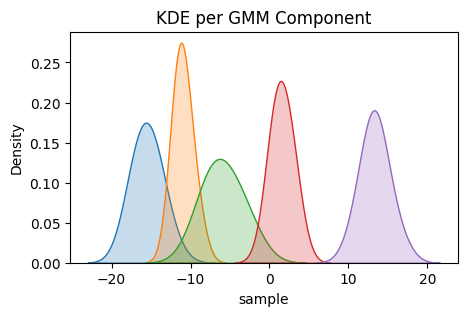

In [8]:
batch_size = 128
num_samples = 100
def gaussian_sample(num_samples):
    startpoint = random.randint(-30,0)
    gmm_centers = generate_5_gmm_centers(1, startpoint)
    print(gmm_centers.numpy())
    gmm_std=2
    print(f"Standard deviation used: {gmm_std}")
    samples, components = draw_gmm_samples(num_samples, gmm_centers, gmm_std)
    data = samples.numpy()
    df = pd.DataFrame({'sample': data[:, 0], 'component': components})
    plt.figure(figsize=(5, 3))
    for comp_id in sorted(df['component'].unique()):
        subset = df[df['component'] == comp_id]
        sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
    plt.title("KDE per GMM Component")
    plt.show()
    return gmm_centers.numpy(), df, gmm_std
gmm_center, temp_data, gmm_std = gaussian_sample(num_samples)

[[-4.9885993]
 [ 4.308356 ]
 [12.611684 ]
 [18.162739 ]
 [26.913576 ]]
Standard deviation used: 2


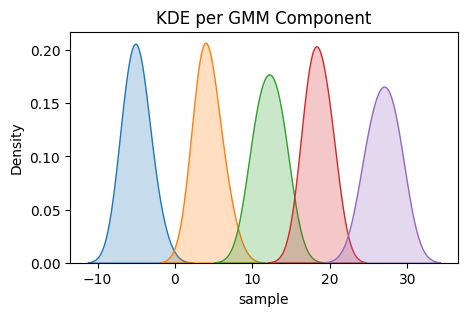

[[ 0.8862254]
 [ 4.326873 ]
 [ 9.878998 ]
 [16.596998 ]
 [30.926289 ]]
Standard deviation used: 2


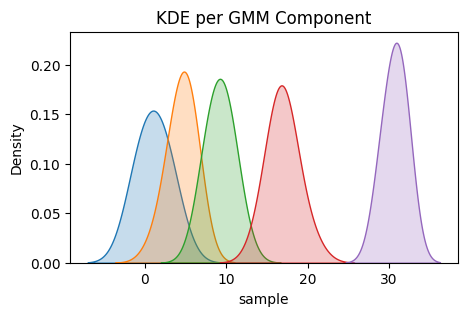

In [19]:
gmm_centers_dim1, df, gmm_std = gaussian_sample(num_samples)
gmm_centers_dim2, df, gmm_std = gaussian_sample(num_samples)
df_gmm_centers_rand = pd.DataFrame(np.squeeze([gmm_centers_dim1, gmm_centers_dim2], axis=-1), columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_rand
df_gmm_centers_rand.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_rand.csv')

In [17]:
np.squeeze(gmm_centers_dim1, axis=-1).shape

(5,)

In [ ]:
df_gmm_centers_box = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_box
df_gmm_centers_box.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box.csv')

In [525]:
gmm_centers_5_new = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_six.csv')
gmm_centers_5_new.values[:, 1:]

array([[-4., -2.,  0.,  2.,  4.],
       [-4., -2.,  0.,  2.,  4.]])

In [526]:
gmm_centers_5_new_np = torch.tensor(list(zip(*gmm_centers_5_new.values[:, 1:]))).float()

5 2
(128, 2)


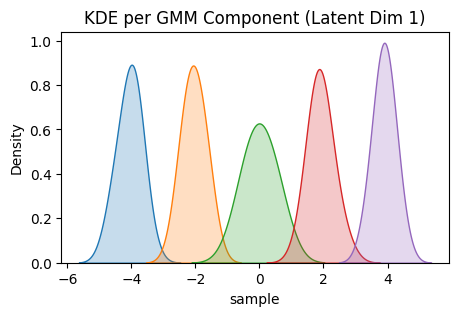

In [536]:
gmm_centers = gmm_centers_5_new_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


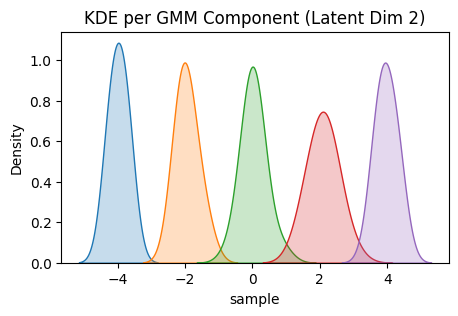

In [537]:
gmm_centers = gmm_centers_5_new_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 2)")
plt.show()

In [474]:
df_gmm_centers = pd.DataFrame(gmm_centers.T, columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_two.csv')

In [538]:
df_gmm_centers

,center1,center2,center3,center4,center5
0,-1.333333,-0.666667,0.0,0.666667,1.333333
1,-1.333333,-0.666667,0.0,0.666667,1.333333


In [3]:
center_0 = [-1, -1, 0, 1, 1]
center_1 = [-1, 1, 0, -1, 1]
df_gmm_centers_box = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_box
df_gmm_centers_box.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_box.csv')

NameError: name 'pd' is not defined

In [544]:
gmm_centers_5_box_np = torch.tensor(list(zip(*df_gmm_centers_box.values))).float()
gmm_centers_5_box_np

tensor([[-1., -1.],
        [-1.,  1.],
        [ 0.,  0.],
        [ 1., -1.],
        [ 1.,  1.]])

5 2
(128, 2)


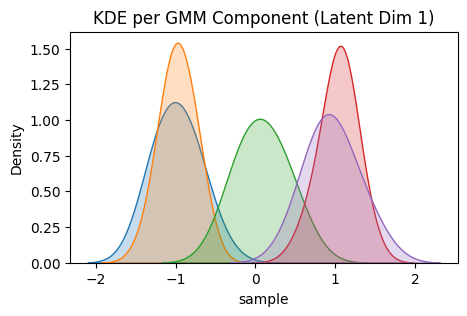

In [550]:
gmm_centers = gmm_centers_5_box_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

In [2]:
gmm_centers = gmm_centers_5_box_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

NameError: name 'gmm_centers_5_box_np' is not defined

In [556]:
center_0 = [-2, 0, -1, 1, 2]
center_1 = [-1, -2, 1, 0, 2]
df_gmm_centers_zigzag = pd.DataFrame([center_0, center_1], columns=['center1', 'center2', 'center3', 'center4', 'center5'])
df_gmm_centers_zigzag
df_gmm_centers_zigzag.to_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/results_DIET/gmm_centers_5_zigzag.csv')

In [553]:
df_gmm_centers_zigzag_np = torch.tensor(list(zip(*df_gmm_centers_zigzag.values))).float()
df_gmm_centers_zigzag_np

tensor([[-2., -1.],
        [ 0., -2.],
        [-1.,  1.],
        [ 1.,  0.],
        [ 2.,  2.]])

5 2
(128, 2)


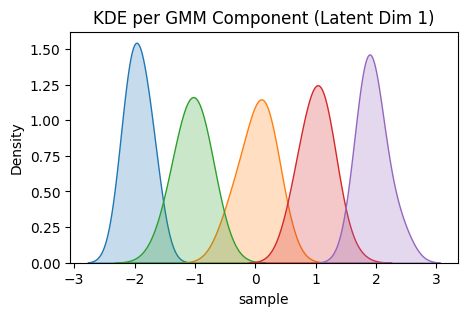

In [554]:
gmm_centers = df_gmm_centers_zigzag_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 0], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 1)")
plt.show()

5 2
(128, 2)


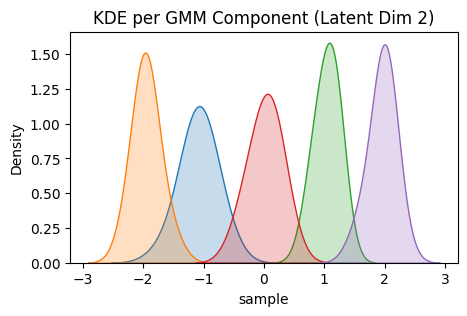

In [555]:
gmm_centers = df_gmm_centers_zigzag_np
samples, components = draw_gmm_samples(128, gmm_centers, gmm_std)
data = samples.numpy()
print(data.shape)
df = pd.DataFrame({'sample': data[:, 1], 'component': components})
plt.figure(figsize=(5, 3))
for comp_id in sorted(df['component'].unique()):
    subset = df[df['component'] == comp_id]
    sns.kdeplot(x=subset['sample'], fill=True, label=f'Component {comp_id}',bw_adjust=2)
plt.title("KDE per GMM Component (Latent Dim 2)")
plt.show()